In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.head(10)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


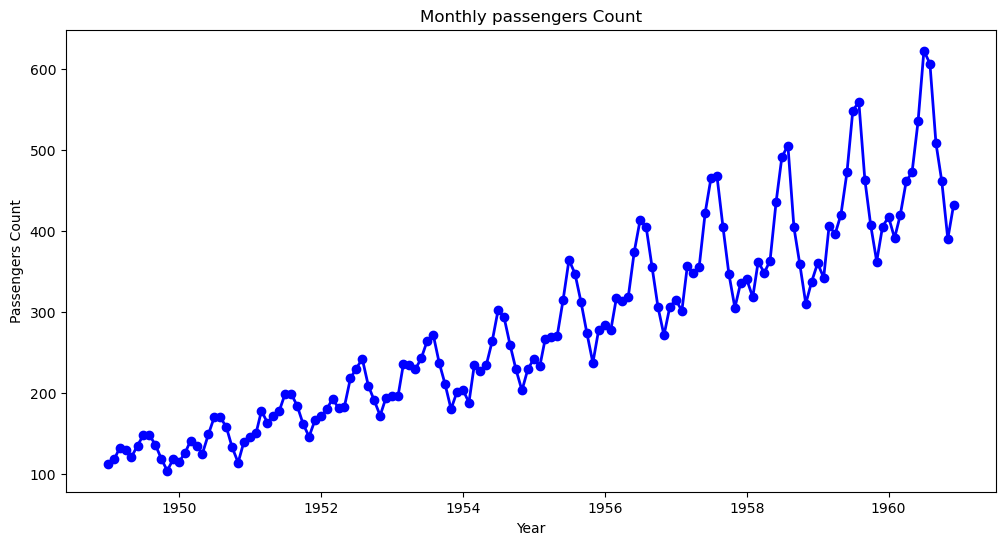

In [4]:
plt.figure(figsize=(12,6))
plt.plot(df, color='blue', marker='o', linestyle='-', linewidth=2, markersize=6)
plt.title('Monthly passengers Count')
plt.xlabel('Year')
plt.ylabel('Passengers Count')
plt.show()

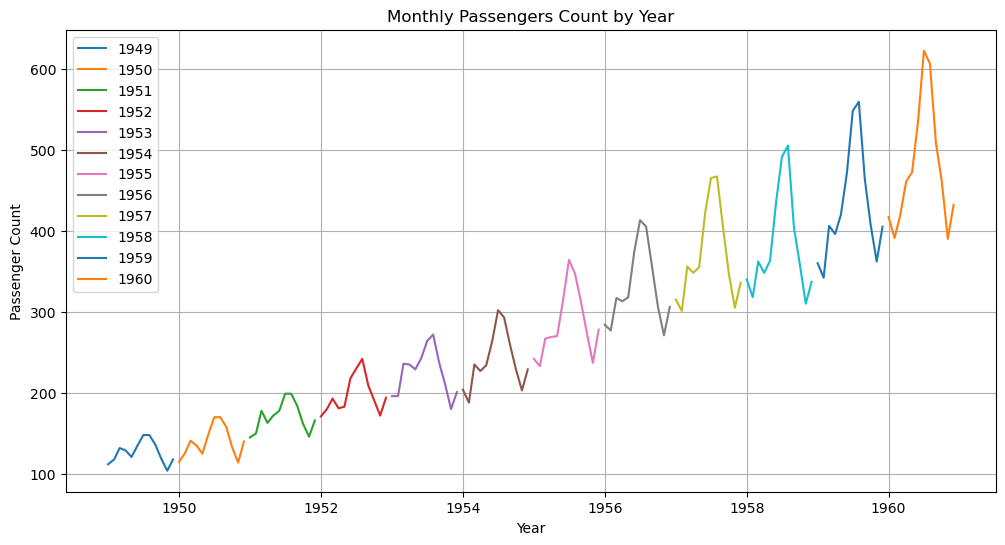

In [5]:
years = df.index.year.unique()

plt.figure(figsize=(12,6))
for year in years:
    year_data = df[df.index.year == year]
    plt.plot(year_data['Passengers'], label=year)
plt.title('Monthly Passengers Count by Year')
plt.xlabel('Year')
plt.ylabel('Passenger Count')
plt.legend()
plt.grid(True)
plt.show()

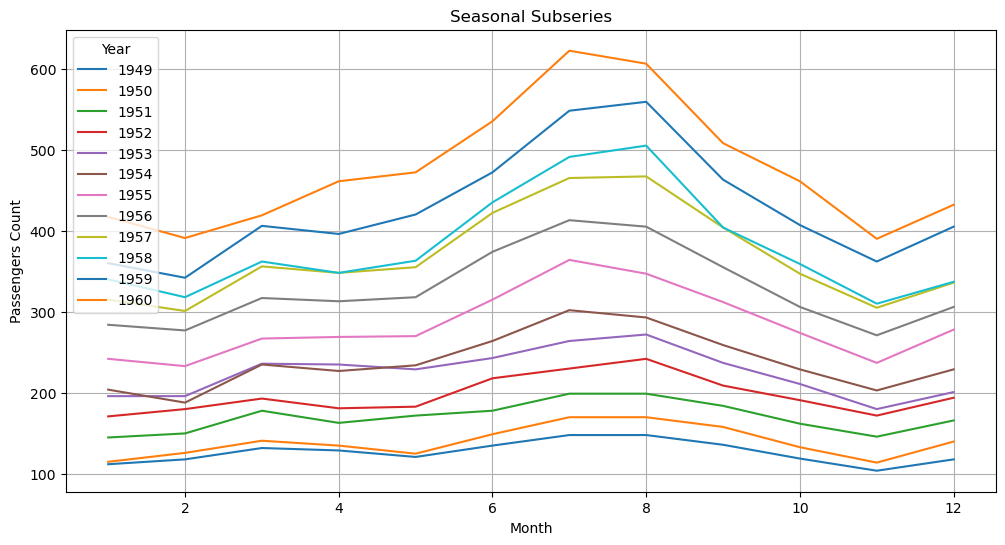

In [6]:
df['Year'] = df.index.year
df['month'] = df.index.month

table = pd.pivot_table(df, values='Passengers', index=['month'], columns='Year', aggfunc='sum')
fig, ax = plt.subplots(figsize=(12, 6))
table.plot(ax=ax, kind='line', legend=True)
ax.set_xlabel('Month')
ax.set_ylabel('Passengers Count')
ax.set_title('Seasonal Subseries')
plt.grid()
plt.show()

C:\Users\arely\AppData\Local\Temp\ipykernel_9104\2064683727.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Passengers'], shade=True)


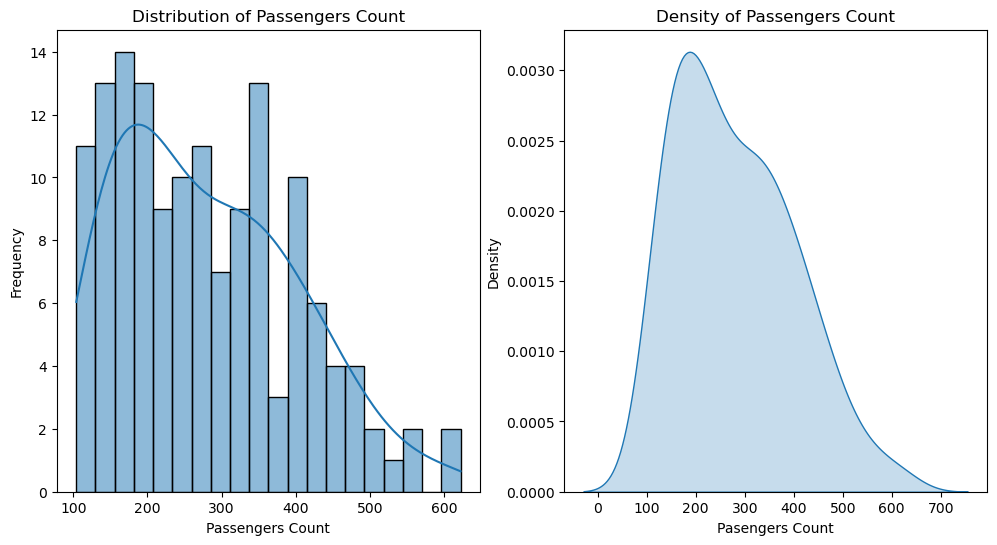

In [7]:
import seaborn as sns

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['Passengers'], bins=20, kde=True)
plt.title('Distribution of Passengers Count')
plt.xlabel('Passengers Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.kdeplot(df['Passengers'], shade=True)
plt.title('Density of Passengers Count')
plt.xlabel('Pasengers Count')
plt.show()

In [8]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

In [9]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4)


In [10]:
def plot_series(s, title):
    s.plot()
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.grid(True)
    plt.show()

def adf_test(x):
    res = adfuller(x, autolag='AIC')
    key = ['test_stat', 'pvalue', 'lags', 'nobs', 'critical_values', 'icbest']
    return dict(zip(key, [res[0], res[1], res[2], res[3], res[4], res[5]]))

def kpss_test(x, regression='c', nlag='auto'):
    stat, pvalue, lags, crit = kpss(x, regression=regression, nlags=nlag)
    return {'test_stat': stat, 'pvalue': pvalue, 'lags': lags, 'critical_values': crit, 'regression': regression}

def print_test(x, name='series'):
    print(f'Test {name}')
    a = adf_test(x)
    print(f'ADF Statistic: {a['test_stat']:.3f} p={a['pvalue']}')
    try:
        k = kpss_test(x)
        print(f'KPSS: stat={k['test_stat']:.3f} p={k['pvalue']}')
    except:
        print('KPSS test failes')

def rolling_mean_var(s, window=24, title='Rolling Mean & Var'):
    rolling_mean = s.rolling(window).mean()
    rolling_var = s.rolling(window).var()
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    ax[0].plot(s, label='Original')
    ax[0].plot(rolling_mean, label='Rolling Mean')
    ax[0].legend()
    ax[0].set_title(title + '- mean')
    ax[1].plot(rolling_var, label='Rolling Var')
    ax[1].legend()
    ax[1].set_title(title + '- var')
    plt.show()


In [11]:
n = 240 #meses
t = np.arange(n)

#stationary: white noise
white_noise = pd.Series(np.random.normal(0,1,n))

#no estacionaria
trend = .02 * t
trended = pd.Series(trend +np.random.normal(0, 1, n))



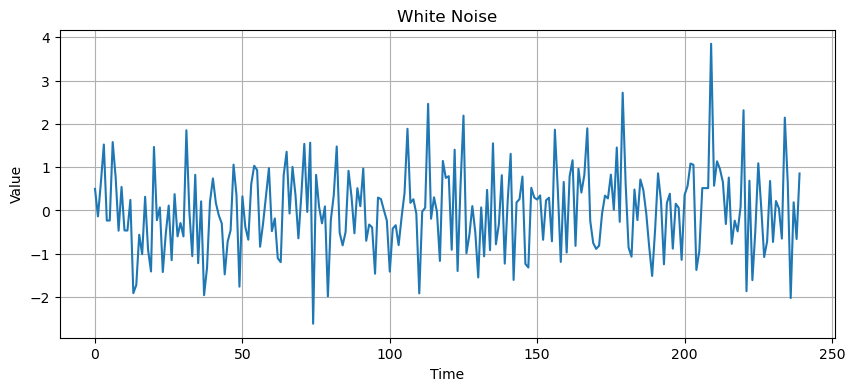

Test White Noise
ADF Statistic: -16.112 p=5.006520467194035e-29
KPSS: stat=0.298 p=0.1


C:\Users\arely\AppData\Local\Temp\ipykernel_9104\827597748.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pvalue, lags, crit = kpss(x, regression=regression, nlags=nlag)


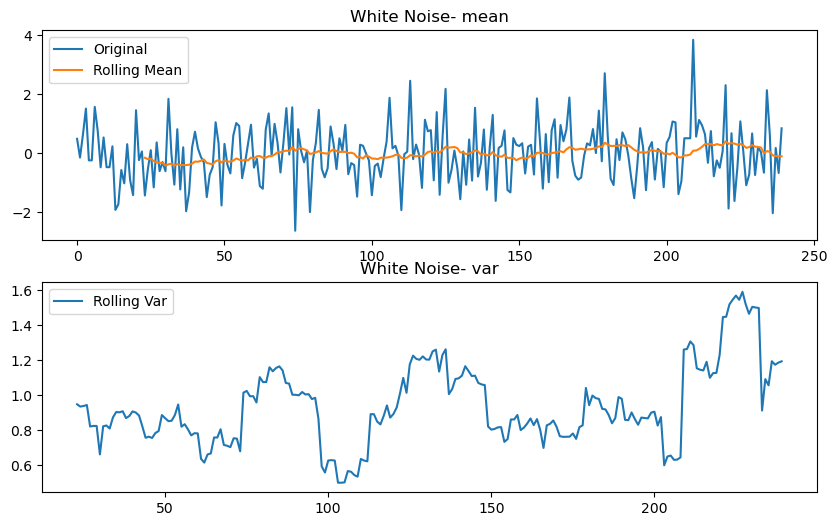

In [12]:
plot_series(white_noise, 'White Noise')
print_test(white_noise, 'White Noise')
rolling_mean_var(white_noise, title='White Noise')

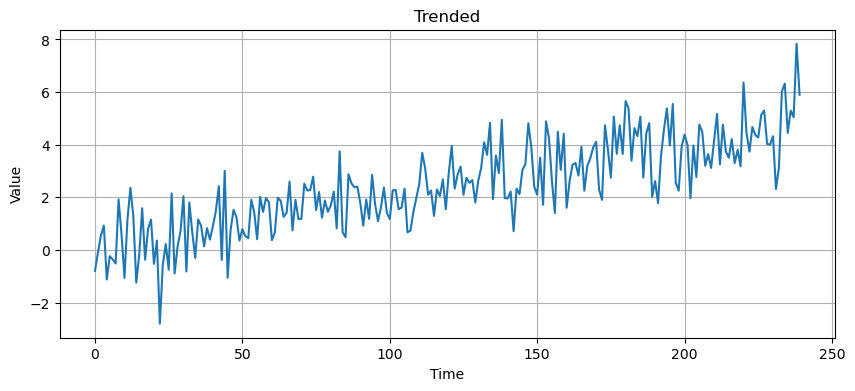

Test Trended
ADF Statistic: -0.057 p=0.9535945013089617
KPSS: stat=2.416 p=0.01


C:\Users\arely\AppData\Local\Temp\ipykernel_9104\827597748.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pvalue, lags, crit = kpss(x, regression=regression, nlags=nlag)


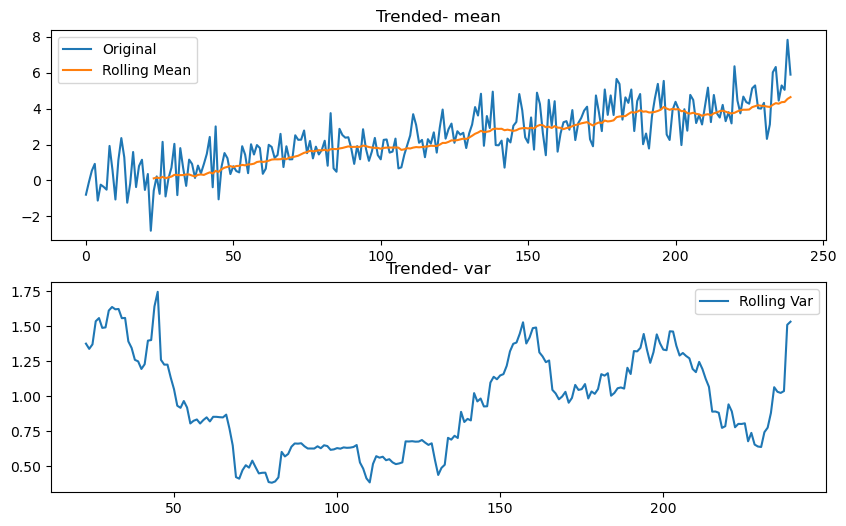

In [13]:
plot_series(trended, 'Trended')
print_test(trended, 'Trended')
rolling_mean_var(trended, window=24, title='Trended')

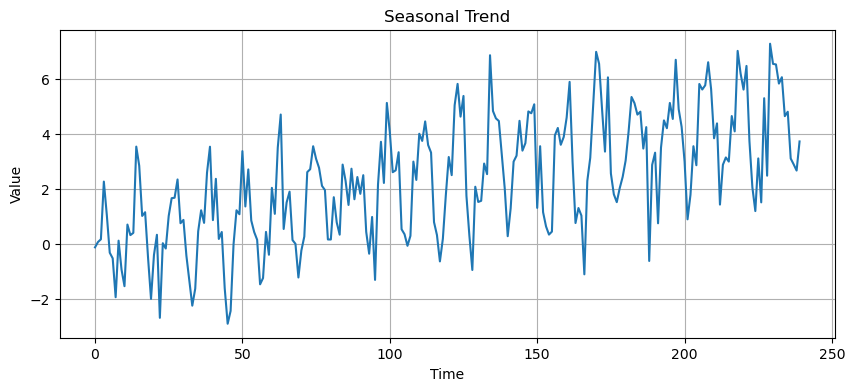

Test Seasonal Trend
ADF Statistic: -0.530 p=0.8860859361543615
KPSS: stat=2.407 p=0.01


C:\Users\arely\AppData\Local\Temp\ipykernel_9104\827597748.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pvalue, lags, crit = kpss(x, regression=regression, nlags=nlag)


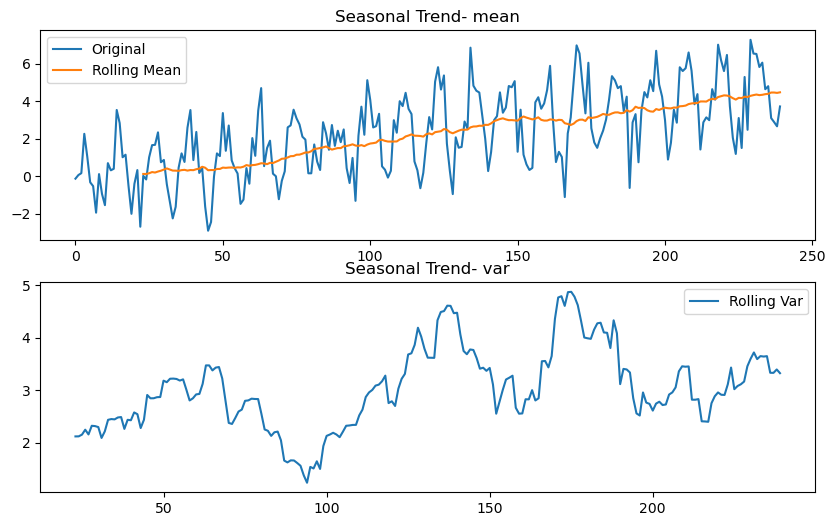

In [20]:
#seasonal  + trend
seasonal = 2 * np.sin(2*np.pi*t/12)
trend = 0.02 * t
season_trend = pd.Series(trend + seasonal + np.random.normal(0,1,n))
plot_series(season_trend, 'Seasonal Trend')
print_test(season_trend, 'Seasonal Trend')
rolling_mean_var(season_trend, window=24, title='Seasonal Trend')

In [21]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.head(10)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [22]:
df.rename(columns={'Passengers':'y'}, inplace=True)
df.head()

,y
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


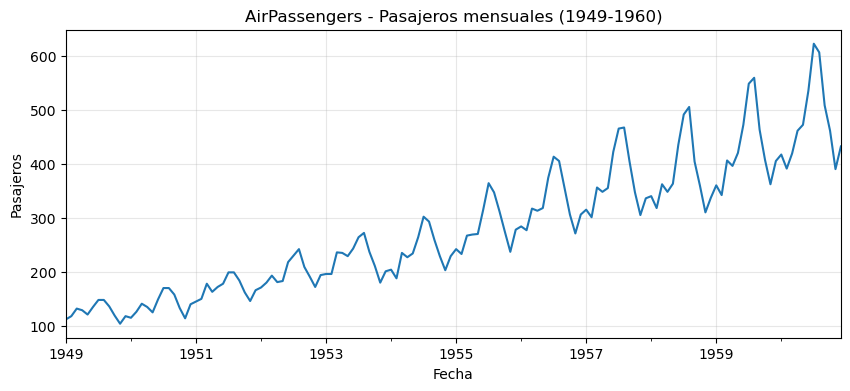

In [23]:
ax = df['y'].plot()
ax.set_title('AirPassengers - Pasajeros mensuales (1949-1960)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Pasajeros')
ax.grid(True, alpha=0.3)
plt.show()

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

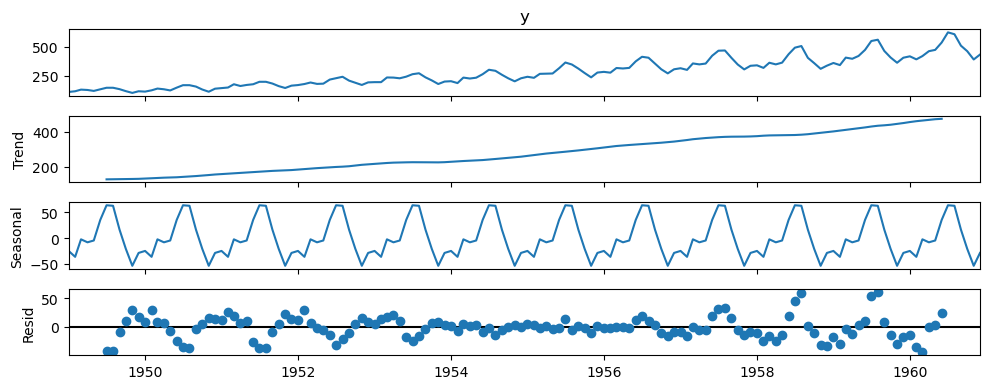

In [25]:
decomp = seasonal_decompose(df['y'], model='additive', period=12)
decomp.plot()
plt.show()

In [29]:
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(df['y'], lags =1)
model_fit = model.fit()

print(model_fit.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  144
Model:                     AutoReg(1)   Log Likelihood                -704.106
Method:               Conditional MLE   S.D. of innovations             33.277
Date:                Thu, 23 Oct 2025   AIC                           1414.212
Time:                        19:28:50   BIC                           1423.100
Sample:                    02-01-1949   HQIC                          1417.823
                         - 12-01-1960                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7055      7.084      1.935      0.053      -0.178      27.589
y.L1           0.9589      0.023     41.106      0.000       0.913       1.005
                                    Roots           

c:\Users\arely\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


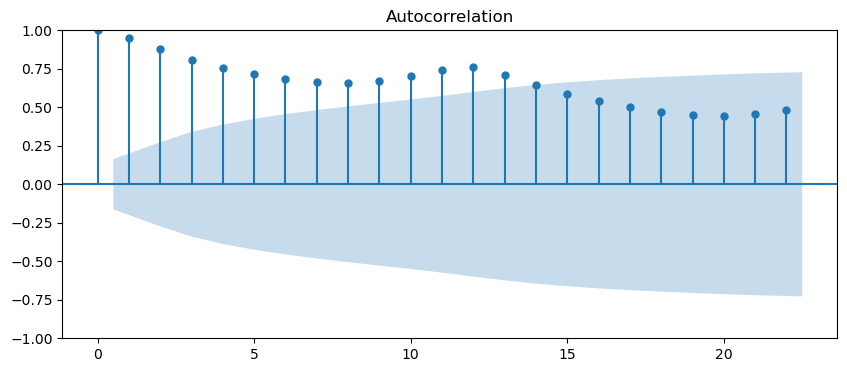

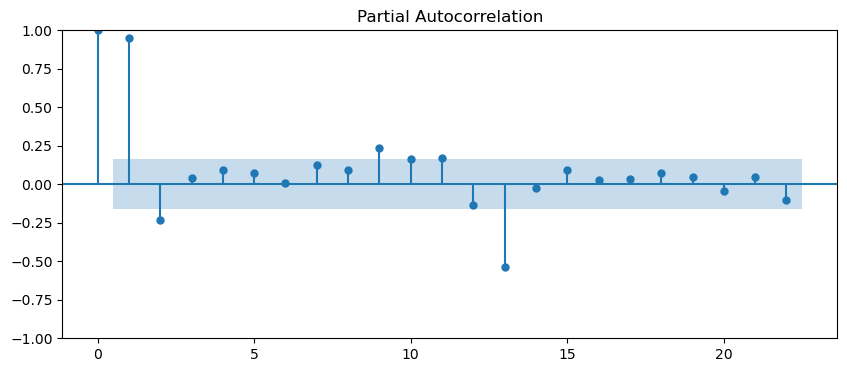

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['y'])
plt.show()
plot_pacf(df['y'])
plt.show()

In [32]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['y'], order = (12,1,1))
model_fit = model.fit()

print(model_fit.summary())

c:\Users\arely\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\arely\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\arely\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\arely\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  144
Model:                ARIMA(12, 1, 1)   Log Likelihood                -558.708
Date:                Thu, 23 Oct 2025   AIC                           1145.417
Time:                        20:54:46   BIC                           1186.897
Sample:                    01-01-1949   HQIC                          1162.272
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1025      0.067      1.538      0.124      -0.028       0.233
ar.L2         -0.0916      0.060     -1.522      0.128      -0.210       0.026
ar.L3          0.0094      0.054      0.174      0.8

c:\Users\arely\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


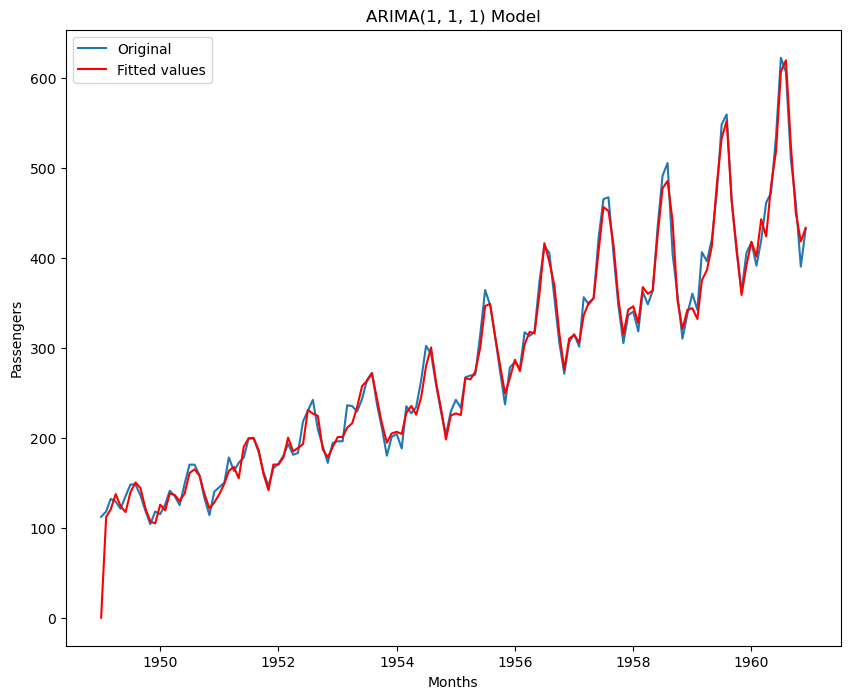

In [33]:
plt.figure(figsize=(10, 8))
plt.plot(df['y'], label = 'Original')
plt.plot(model_fit.fittedvalues, color = 'red', label = 'Fitted values')
plt.title('ARIMA(1, 1, 1) Model')
plt.xlabel('Months')
plt.ylabel('Passengers')
plt.legend()
plt.show()

Ejercicio

In [14]:
sunspots = pd.read_csv('Sunspots.csv')
sunspots.head()

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7


In [15]:
sunspots['Date'] = pd.to_datetime(sunspots['Date'])
sunspots = sunspots.set_index('Date')

sunspots.head()

,Unnamed: 0,Monthly Mean Total Sunspot Number
Date,,
1749-01-31,0,96.7
1749-02-28,1,104.3
1749-03-31,2,116.7
1749-04-30,3,92.8
1749-05-31,4,141.7


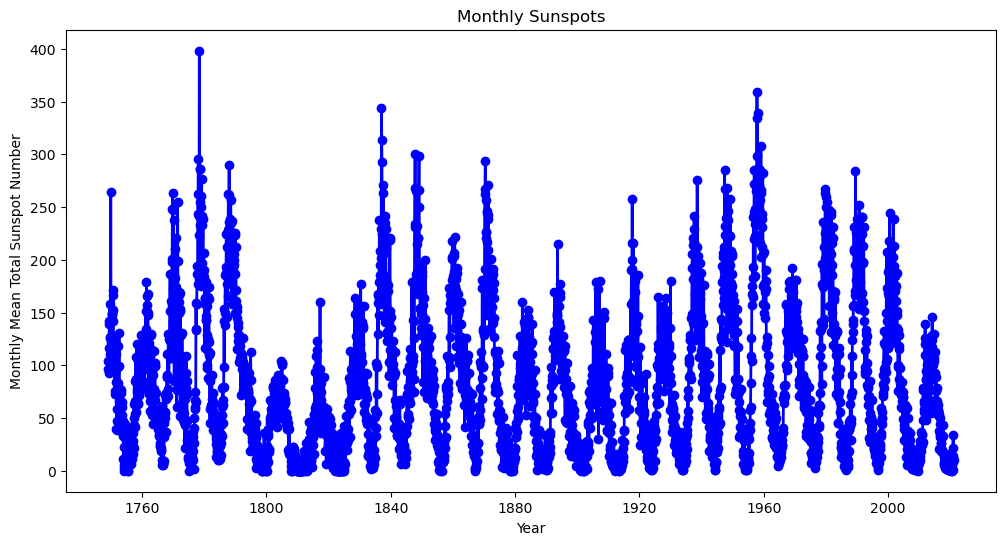

In [16]:
plt.figure(figsize=(12,6))
plt.plot(sunspots.index, sunspots['Monthly Mean Total Sunspot Number'], color='blue', marker='o', linestyle='-', linewidth=2, markersize=6)
plt.title('Monthly Sunspots')
plt.xlabel('Year')
plt.ylabel('Monthly Mean Total Sunspot Number')
plt.show()

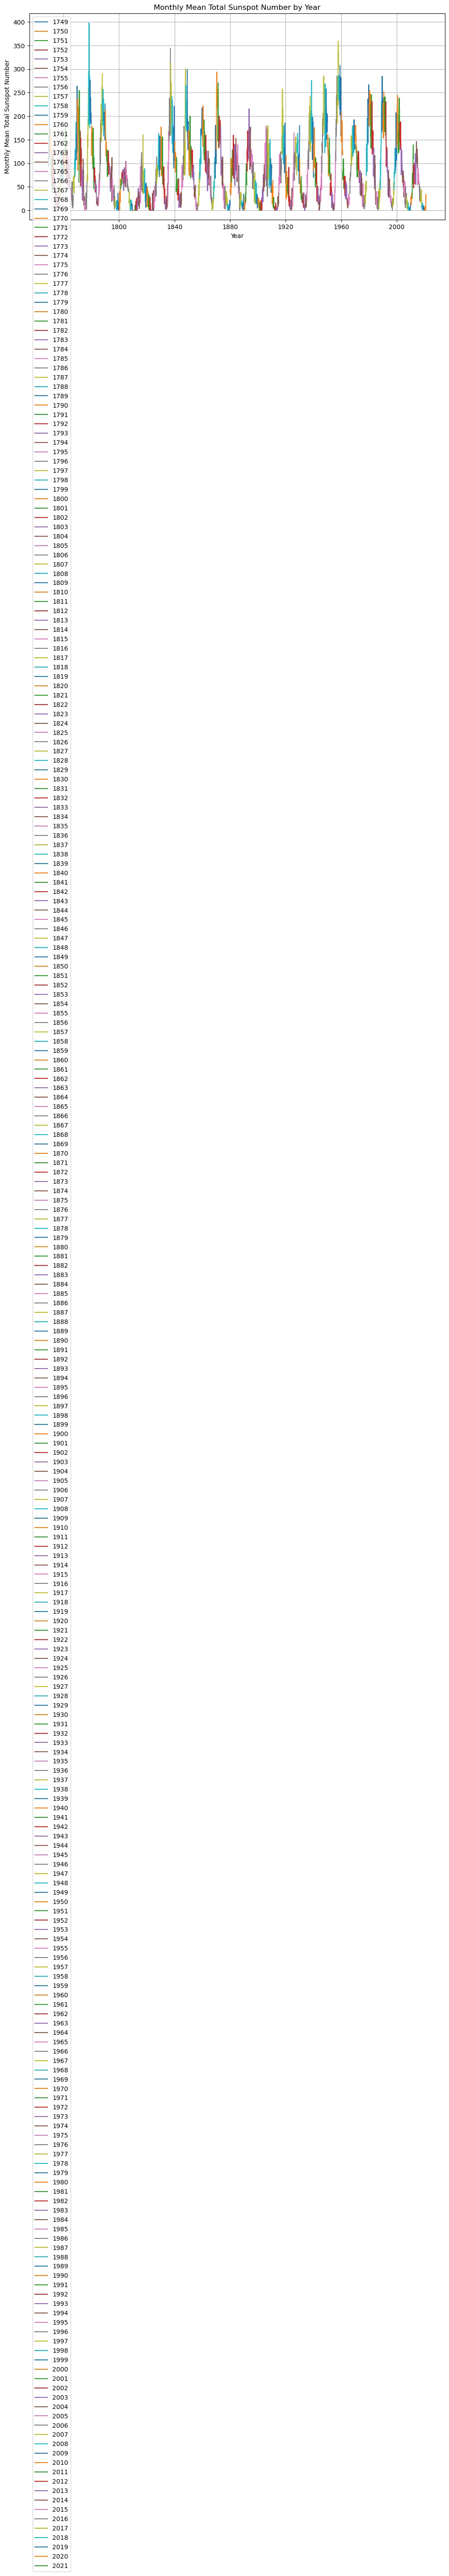

In [17]:
years = sunspots.index.year.unique()

plt.figure(figsize=(12,6))
for year in years:
    year_data = sunspots[sunspots.index.year == year]
    plt.plot(year_data['Monthly Mean Total Sunspot Number'], label=year)
plt.title('Monthly Mean Total Sunspot Number by Year')
plt.xlabel('Year')
plt.ylabel('Monthly Mean Total Sunspot Number')
plt.legend()
plt.grid(True)
plt.show()

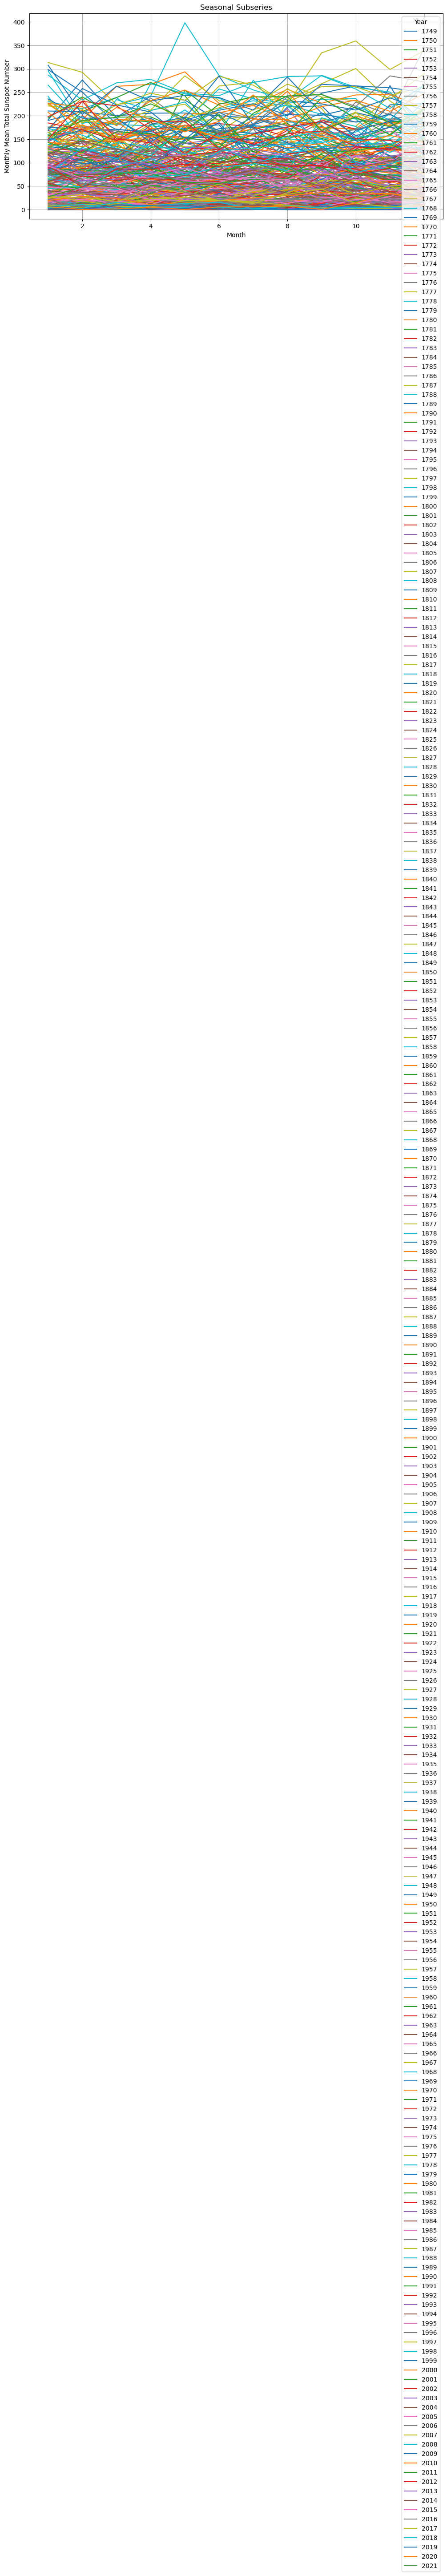

In [18]:
sunspots['Year'] = sunspots.index.year
sunspots['month'] = sunspots.index.month

table = pd.pivot_table(sunspots, values='Monthly Mean Total Sunspot Number', index=['month'], columns='Year', aggfunc='sum')
fig, ax = plt.subplots(figsize=(12, 6))
table.plot(ax=ax, kind='line', legend=True)
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Mean Total Sunspot Number')
ax.set_title('Seasonal Subseries')
plt.grid()
plt.show()

C:\Users\arely\AppData\Local\Temp\ipykernel_9104\2422498988.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(sunspots['Monthly Mean Total Sunspot Number'], shade=True)


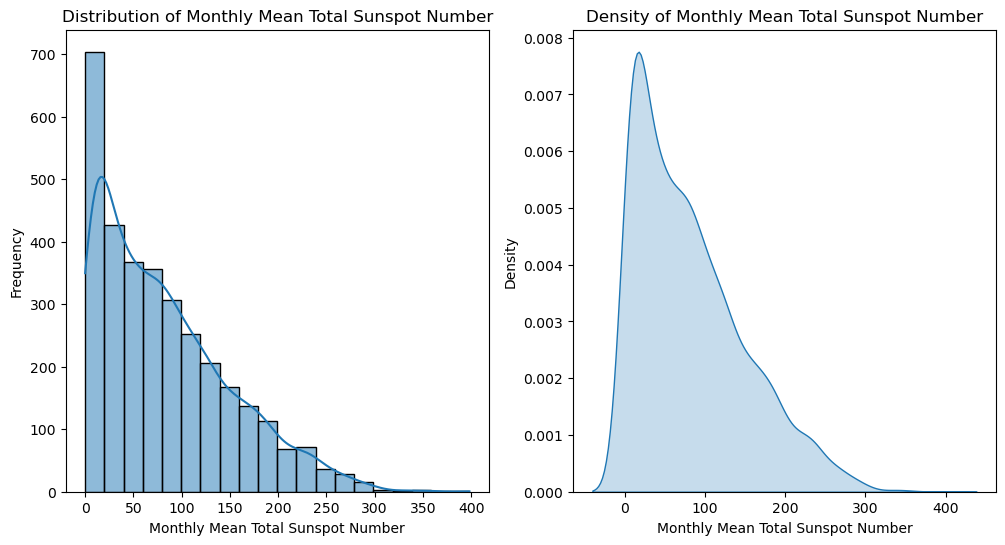

In [19]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(sunspots['Monthly Mean Total Sunspot Number'], bins=20, kde=True)
plt.title('Distribution of Monthly Mean Total Sunspot Number')
plt.xlabel('Monthly Mean Total Sunspot Number')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.kdeplot(sunspots['Monthly Mean Total Sunspot Number'], shade=True)
plt.title('Density of Monthly Mean Total Sunspot Number')
plt.xlabel('Monthly Mean Total Sunspot Number')
plt.show()